## Define Variables / Import MetaData

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from cartopy import crs as ccrs 
import cartopy.feature as cfeature
import pandas as pd
import hvplot.pandas
import xarray as xr
import hvplot.xarray
import geoviews.feature as gf

In [2]:
# Define misc variables 
# I can't get the config.py to work in jupyternotebook because it does not know where $NOBACKUP is
amer_filepath = '../../ameriflux-data/'
mic_filepath = '../intermediates/'

In [3]:
# Import site metadata csv
meta_file = amer_filepath + 'AmeriFlux-site-search-results-202410071335.tsv'
ameriflux_meta = pd.read_csv(meta_file, sep='\t')
fluxnet_meta = ameriflux_meta.loc[ameriflux_meta['AmeriFlux FLUXNET Data'] == 'Yes'] 

In [4]:
# set map proj
proj=ccrs.PlateCarree()

## RSME plotting

In [5]:
# Create df with lat/lons
site_subset = ['Site ID', 
               'Longitude (degrees)',
                'Latitude (degrees)',
               ]
df_meta = fluxnet_meta[site_subset]
df_meta.set_index('Site ID')

,Longitude (degrees),Latitude (degrees)
Site ID,,
AR-TF1,-66.7335,-54.9733
BR-CST,-38.3842,-7.9682
BR-Npw,-56.4120,-16.4980
CA-ARB,-83.9452,52.6950
CA-ARF,-83.9550,52.7008
...,...,...
US-xTR,-89.5857,45.4937
US-xUK,-95.1921,39.0404
US-xUN,-89.5373,46.2339


In [6]:
# Import and merge results
results = pd.read_csv('../analysis/results.csv',index_col='SiteID')
results

,NEE_RSME,NPP_RSME
SiteID,,
AR-TF1,8.724631e-09,5.747991e-09
BR-CST,1.728019e-08,1.126854e-08
BR-Npw,2.956383e-08,1.592488e-08
CA-ARB,6.452837e-09,9.849190e-09
CA-ARF,8.136552e-09,9.839452e-09
...,...,...
US-xTR,2.149878e-08,1.333941e-08
US-xUK,1.948348e-08,1.664799e-08
US-xUN,2.017470e-08,1.503207e-08


In [7]:
df = df_meta.join(results, on='Site ID')
df

,Site ID,Longitude (degrees),Latitude (degrees),NEE_RSME,NPP_RSME
5,AR-TF1,-66.7335,-54.9733,8.724631e-09,5.747991e-09
9,BR-CST,-38.3842,-7.9682,1.728019e-08,1.126854e-08
18,BR-Npw,-56.4120,-16.4980,2.956383e-08,1.592488e-08
25,CA-ARB,-83.9452,52.6950,6.452837e-09,9.849190e-09
26,CA-ARF,-83.9550,52.7008,8.136552e-09,9.839452e-09
...,...,...,...,...,...
664,US-xTR,-89.5857,45.4937,2.149878e-08,1.333941e-08
665,US-xUK,-95.1921,39.0404,1.948348e-08,1.664799e-08
666,US-xUN,-89.5373,46.2339,2.017470e-08,1.503207e-08
667,US-xWD,-99.2414,47.1282,1.285436e-08,8.416917e-09


In [8]:
ds = xr.Dataset(
    coords={
        'site_id': df['Site ID'].values,
        'lat': ('site_id', df['Latitude (degrees)'].values),
        'lon': ('site_id', df['Longitude (degrees)'].values),
    }, 
    data_vars={
        'NEE_RSME': ("site_id", df['NEE_RSME'].values),
        'NPP_RSME': ("site_id", df['NPP_RSME'].values),
    }
)

In [9]:
ds

<xarray.Dataset> Size: 8kB
Dimensions:   (site_id: 196)
Coordinates:
  * site_id   (site_id) object 2kB 'AR-TF1' 'BR-CST' ... 'US-xWD' 'US-xYE'
    lat       (site_id) float64 2kB -54.97 -7.968 -16.5 ... 46.23 47.13 44.95
    lon       (site_id) float64 2kB -66.73 -38.38 -56.41 ... -99.24 -110.5
Data variables:
    NEE_RSME  (site_id) float64 2kB 8.725e-09 1.728e-08 ... 1.285e-08 1.268e-08
    NPP_RSME  (site_id) float64 2kB 5.748e-09 1.127e-08 ... 8.417e-09 2.893e-05

### Xarray matplotlib

In [10]:
from matplotlib.colors import ListedColormap

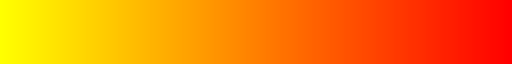

In [11]:
# Make transparency colormap:
cmap = plt.cm.autumn_r
cmap

In [12]:
cmap(np.arange(cmap.N)).shape

(256, 4)

In [13]:
cmap(1)

(np.float64(1.0),
 np.float64(0.996078431372549),
 np.float64(0.0),
 np.float64(1.0))

In [14]:
my_cmap = cmap(np.arange(cmap.N))
my_cmap[:, -1] = np.linspace(0, 1, cmap.N)
my_cmap[-1]

array([1., 0., 0., 1.])

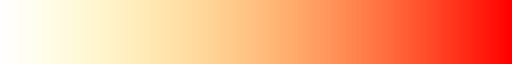

In [15]:
my_cmap = ListedColormap(my_cmap)
my_cmap

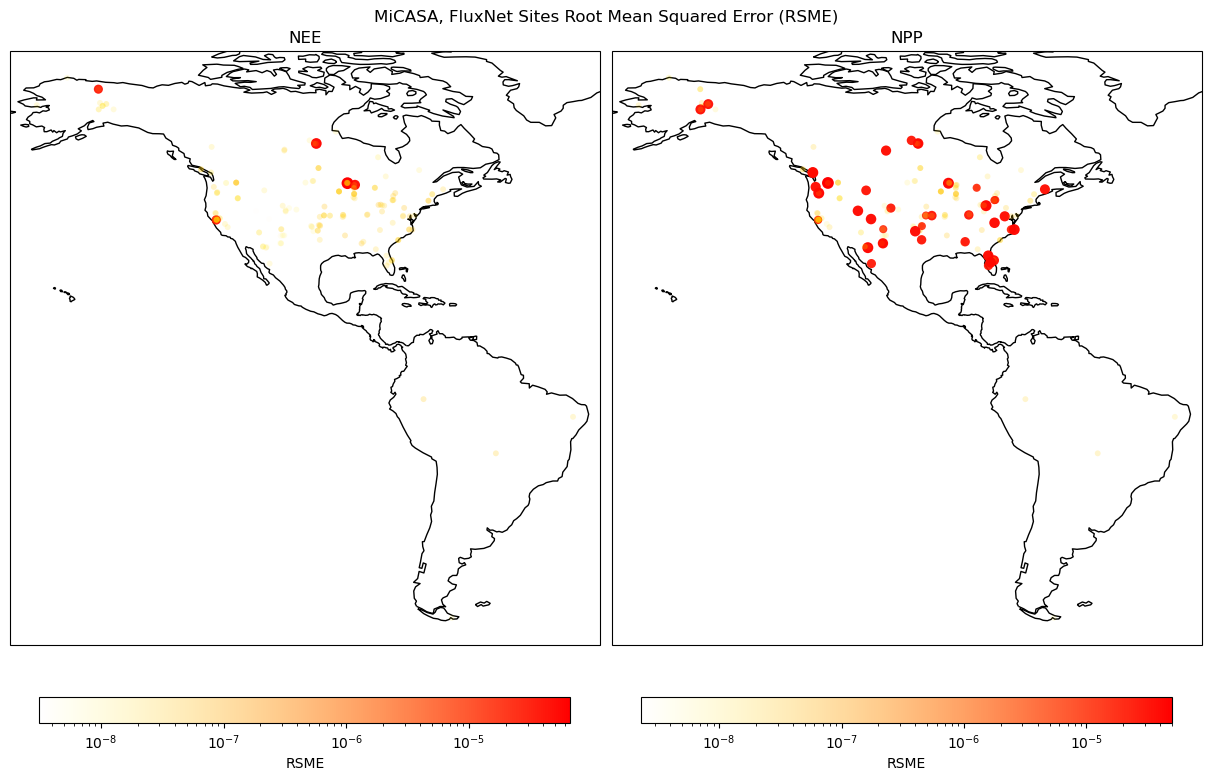

In [16]:
fig, axs = plt.subplots(1,2,figsize=(12, 10), subplot_kw={'projection': proj}, constrained_layout=True);
fig.suptitle('MiCASA, FluxNet Sites Root Mean Squared Error (RSME)', y=0.76)
values =['NEE_RSME', 'NPP_RSME']
for ax,val in zip(axs, values):
    ax.add_feature(cfeature.COASTLINE,zorder=0)
    plot = ds.plot.scatter(x="lon", y="lat",ax=ax,
                           
                           markersize=val, edgecolor='none',add_legend=False,
                           
                            norm=colors.LogNorm(), 
                            # norm=colors.LogNorm(vmin=ds[val].min(), vmax=ds[val].max()),
                           hue=val,
                           cmap=my_cmap,
                           # cmap='cool',
                           # cmap='autumn_r',
                           add_colorbar=False
                          )
    
    cbar = fig.colorbar(plot, ax=ax, shrink=0.9, label=val[4:], orientation='horizontal')
    ax.set_title(val[:3])
plt.show()

#### Try ipympl? It doesn't seem to work

In [17]:
import ipympl

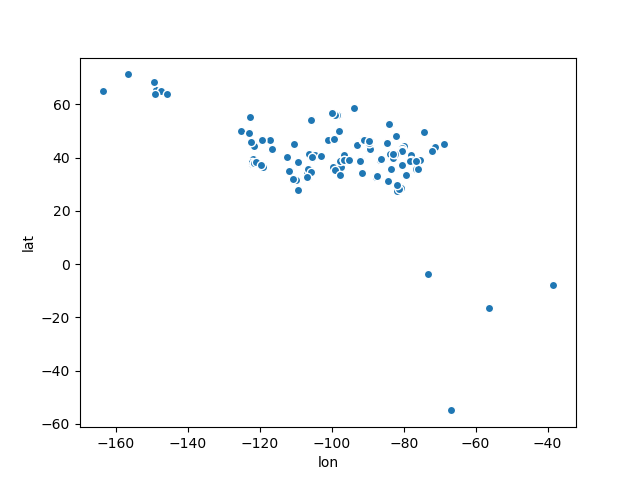

In [18]:
%matplotlib ipympl
ds.plot.scatter(x="lon", y="lat")

In [19]:
# !jupyter labextension list

In [20]:
%matplotlib inline

#### Xarray bokeh plot? This doesn't work so I have to plot the dataframe

In [21]:
# ds_NEE = ds[values[0]]
# ds_NEE

In [22]:
# hv.extension('bokeh', inline=True)
# ds_NEE.hvplot.points(x='lon', y='lat',
#                       geo=True,
#                      # crs=proj, 
#                     # project=True
#                      )

# ds_dropped = ds_NEE.drop_indexes("site_id")
# ds_dropped = ds_dropped.drop_vars("site_id")
# ds_dropped

### Pandas Holoviews

In [23]:
df.head()

,Site ID,Longitude (degrees),Latitude (degrees),NEE_RSME,NPP_RSME
5,AR-TF1,-66.7335,-54.9733,8.724631e-09,5.747991e-09
9,BR-CST,-38.3842,-7.9682,1.728019e-08,1.126854e-08
18,BR-Npw,-56.4120,-16.4980,2.956383e-08,1.592488e-08
25,CA-ARB,-83.9452,52.6950,6.452837e-09,9.849190e-09
26,CA-ARF,-83.9550,52.7008,8.136552e-09,9.839452e-09


In [24]:
import xyzservices.providers as xyz
from matplotlib.ticker import LogFormatter

In [25]:
min_lon, max_lon = df["Longitude (degrees)"].min(), df["Longitude (degrees)"].max()
min_lat, max_lat = df["Latitude (degrees)"].min(), df["Latitude (degrees)"].max()

print(min_lon, max_lon)
print(min_lat, max_lat)

-163.7002 -38.3842
-54.9733 71.2824


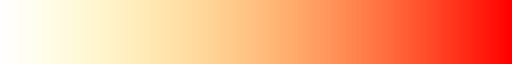

In [26]:
my_cmap

In [27]:
plot = df.hvplot.points(x="Longitude (degrees)", 
                        y="Latitude (degrees)",
                        geo=True, 
                        crs=ccrs.PlateCarree(),
                        # projection=ccrs.PlateCarree(), # Doesn't work with tiles

                         #Custom cmap with transparency won't show up in bokeh
                        c=values[0],
                        logz=True,
                        cmap=my_cmap,
                        clabel=f'{values[0]}',

                         size=45,
                         # Size values don't scale logarithmically
                        # s=values[0],
                        # scale=4500,
                         # color='red',
                        
                        tiles=True,
                        tiles_opts={'alpha': 0.4},
                        # tiles=xyz.Esri.WorldGrayCanvas,


                        hover_cols=['Site ID'],

                        # width=700, height=500,
                        # xlim=(-165, -40),   # longitude range
                        # ylim=(-60, 75),     # latitude range
                        frame_width=800,
                        frame_height=500
                                           )
plot

:Overlay
   .WMTS.I   :WMTS   [Longitude,Latitude]
   .Points.I :Points   [Longitude (degrees),Latitude (degrees)]   (NEE_RSME,Site ID)

In [28]:
# Try to scale size by log:
# df_scale = df.copy()
# df_scale["log_NEE_RSME"] = np.log(df_scale["NEE_RSME"])
# df_scale.head()

# **** This doesn't work because the logs are negative- would have to create a pseudo log scale but this is complex ******

In [29]:
plot * gf.coastline

:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Points.I    :Points   [Longitude (degrees),Latitude (degrees)]   (NEE_RSME,Site ID)
   .Coastline.I :Feature   [Longitude,Latitude]

## Run a random example

In [30]:
import numpy as np
import xarray as xr

lat = np.linspace(-90, 90, 5)
lon = np.linspace(-180, 180, 5)
data = np.random.rand(len(lat), len(lon))

ds_ex = xr.DataArray(data, coords=[('lat', lat), ('lon', lon)], name='val')

ds_ex.hvplot.image(x='lon', y='lat')  # no geo=True yet

:Image   [lon,lat]   (val)

In [31]:
ds_ex

<xarray.DataArray 'val' (lat: 5, lon: 5)> Size: 200B
array([[0.71388121, 0.32864599, 0.00870345, 0.82494052, 0.15231791],
       [0.49713025, 0.80677011, 0.16214832, 0.87459626, 0.94895208],
       [0.33521659, 0.47842748, 0.34770737, 0.75348474, 0.70343007],
       [0.76103996, 0.33028897, 0.06045042, 0.18101594, 0.85004163],
       [0.76883256, 0.69876609, 0.28962191, 0.48341413, 0.6574521 ]])
Coordinates:
  * lat      (lat) float64 40B -90.0 -45.0 0.0 45.0 90.0
  * lon      (lon) float64 40B -180.0 -90.0 0.0 90.0 180.0

In [32]:
ds_ex.hvplot.points(x="lon", y="lat", 
                 # c=val,
                    geo=True,
                  projection=proj,
                 # coastline=True,
                 )

:Points   [lon,lat]   (val)

## Try geopandas?

In [33]:
# import geopandas as gpd
# from shapely.geometry import Point


In [34]:
# gdf = gpd.GeoDataFrame(
#     {"site_id": ds["site_id"].values},
#     geometry=[Point(xy) for xy in zip(ds["lon"].values, ds["lat"].values)],
#     crs="EPSG:4326"
# )